# Online Retail Dataset
This is the **Online Retail Dataset** gotten from Kaggle. This dataset contains all purchases made from an online retail company based in the UK during an eight-month period.

## Importing Python libraries to help with analysis and visualization


In [1]:
import pandas as pd # for data manipulation and cleaning
import numpy as np # for arrays and math operations
import matplotlib.pyplot as plt # for basic plotting
import seaborn as sns # for nicer statistical plots
import plotly.express as px # for interactive charts with one line of code
print("All libraries have been successfully imported")

All libraries have been successfully imported


## Load the dataset after importing the needed libraries

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding ="latin-1") #Pretty much any variable can be used, it doesn't have to be df, but we use df because it is short
df.head()
print("File accessed, let's fire on")


File accessed, let's fire on


In [3]:
df.head() #To read the first five rows of the dataframe

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


From df.head() that we ran, it is obvious the dataset has 8 columns

In [4]:
df.info() # This gives a summary of the dataframe's structure. It shows rows and columns, column names, data types of each column, not-null count and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


We have 8 columns, 541909 entries and missing values in description and customerID columns. We also have two float columns, one integer column and five object columns. The object columns seem to me like alphanumeric, string, etc

The numerical columns are the Quantity, UnitPrice columns while the categorical columns are InvoiceNo, StockCode, Description, Invoice Date, Country, CustomerID

The potential primary keys here are: InvoiceNo, CustomerID

## Handling Missing values
The missing values are from **Description** and **CustomerID** columns. Let's have them displayed:

In [5]:
df[df['Description'].isna()] # I am displaying the rows that have a missing description value

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


So, 1454 rows have empty values for descrription. Let's fix that

In [6]:
df['Description'].unique() # To uniquely display the values in the description volumn

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'lost',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], shape=(4224,), dtype=object)

In [7]:
mapping = df.loc[df['Description'].notna()].drop_duplicates('StockCode').set_index('StockCode')['Description']

In [8]:
df['Description'] = df['Description'].fillna(df['StockCode'].map(mapping))

In [9]:
df.loc[df['Description'].isna(),['StockCode','Description']]

,StockCode,Description
1970,21134,NaN
1987,85226A,NaN
1988,85044,NaN
2024,20950,NaN
2026,84670,NaN
...,...,...
280754,21610,NaN
281615,37477B,NaN
281616,37477C,NaN
346849,35592T,NaN


In [10]:
missing = df[df['Description'].isna()]

In [11]:
missing[['StockCode','Description']].drop_duplicates()

,StockCode,Description
1970,21134,NaN
1987,85226A,NaN
1988,85044,NaN
2024,20950,NaN
2026,84670,NaN
...,...,...
280754,21610,NaN
281615,37477B,NaN
281616,37477C,NaN
346849,35592T,NaN


In [12]:
missing[['InvoiceNo', 'StockCode', 'Quantity','UnitPrice']].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice
1970,536545,21134,1,0.0
1987,536549,85226A,1,0.0
1988,536550,85044,1,0.0
2024,536552,20950,1,0.0
2026,536554,84670,23,0.0
7187,536995,35951,57,0.0
7193,537001,21653,-6,0.0
19628,537875,20849,1,0.0
19631,537878,72803B,1,0.0
21782,538133,85018C,3,0.0


From these, we fnd out that some quantities have negative values, which might mean cancelled orders, refunds, reversed transactions, returned items. 

In [13]:
negative_qty = df[df['Quantity']<0]
negative_qty[['InvoiceNo', 'Quantity', 'UnitPrice', 'CustomerID']].head(20)

,InvoiceNo,Quantity,UnitPrice,CustomerID
141,C536379,-1,27.50,14527.0
154,C536383,-1,4.65,15311.0
235,C536391,-12,1.65,17548.0
236,C536391,-24,0.29,17548.0
237,C536391,-24,0.29,17548.0
238,C536391,-24,0.29,17548.0
239,C536391,-12,3.45,17548.0
240,C536391,-12,1.65,17548.0
241,C536391,-24,1.65,17548.0
939,C536506,-6,4.25,17897.0


In [14]:
#Now, let us count the number of transactions that were cancelled
negative_qty['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [15]:
#From the observation above, we see that there were over 9000 cancelled transactions. let's proceed further and inspect those that do not start with c
anomalies = negative_qty[~negative_qty['InvoiceNo'].astype(str).str.startswith('C')]
anomalies.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,RECIPE BOX WITH METAL HEART,-10,12/1/2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,MIRROR LOVE BIRD T-LIGHT HOLDER,-38,12/2/2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,CARD DOLLY GIRL,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,PENNY FARTHING BIRTHDAY CARD,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,CREAM SWEETHEART WALL CABINET,-6,12/3/2010 15:30,0.0,NaN,United Kingdom
7192,537000,21414,SCALLOP SHELL SOAP DISH,-22,12/3/2010 15:32,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,12/3/2010 15:33,0.0,NaN,United Kingdom
7195,537003,85126,LARGE ROUND CUTGLASS CANDLESTICK,-2,12/3/2010 15:33,0.0,NaN,United Kingdom
7196,537004,21814,HEART T-LIGHT HOLDER,-30,12/3/2010 15:34,0.0,NaN,United Kingdom
7197,537005,21692,SILVER LATTICE VANILLA CANDLE POT,-70,12/3/2010 15:35,0.0,NaN,United Kingdom


In [16]:
negative_qty[negative_qty['InvoiceNo'].astype(str).str.startswith('C')]['InvoiceNo'].nunique()

3836

So, there were 3836 unique cancellation values, meaning each cancellation invoice contains about 2-3 product line items on average

## Removing rows where unit price is less than zero and CustomerID is missing 
These rows usually represent non-sales activity

In [18]:
non_sales = df[(df['UnitPrice'] <=0) & (df['CustomerID'].isna())]
non_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,RETROSPOT TEA SET CERAMIC 11 PC,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,CHRISTMAS CRAFT HEART STOCKING,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NEW ENGLAND MUG W GIFT BOX,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [19]:
non_sales.shape

(2477, 8)

In [21]:
df_clean = df[~((df['UnitPrice'] <= 0) & (df['CustomerID'].isna()))]

Now, we have removed rows that appear to represent non-sales operational requirements : Missing CustomerID, Zero or missing UnitPrice or negative quantities.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  541797 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [23]:
#Let us find out the number of rows per cancellation invoice
cancel_counts = negative_qty.groupby('InvoiceNo').size()
cancel_counts.describe()

count    5172.000000
mean        2.054138
std         3.297205
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       101.000000
dtype: float64

In [24]:
#Let us sort the largest cancellation invoices
cancel_counts.sort_values(ascending = False).head(10)

InvoiceNo
C570867    101
C560540     57
C548460     45
C560855     41
C538341     39
C570828     39
C557663     38
C569985     36
C542426     35
C559939     32
dtype: int64

In [25]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132603
Country             0
dtype: int64

In [27]:
df_clean[df_clean['Description'].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [28]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [30]:
## Creating a revenue column
df_clean = df[df['UnitPrice'] > 0].copy()
df_clean['Revenue']=df_clean['Quantity'] * df_clean['UnitPrice']

In [31]:
#Converting date column
df_clean['InvoiceDate'] =pd.to_datetime(df_clean['InvoiceDate'])

In [32]:
df_clean['Month']= df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

In [33]:
df_clean.describe() #To generate summary statistics

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Month,Day,Hour
count,539392.000000,539392,539392.000000,406789.000000,539392.000000,539392.000000,539392.000000,539392.000000
mean,9.845904,2011-07-04 16:40:36.232350208,4.673648,15287.795830,18.112749,7.555805,15.018812,13.076938
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000,-168469.600000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 11:59:00,1.250000,13954.000000,3.750000,5.000000,7.000000,11.000000
50%,3.000000,2011-07-20 11:50:00,2.080000,15152.000000,9.840000,8.000000,15.000000,13.000000
75%,10.000000,2011-10-19 11:49:00,4.130000,16791.000000,17.400000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,12.000000,31.000000,20.000000
std,215.412652,NaN,94.614722,1713.573064,379.091706,3.508831,8.660654,2.443495


In [34]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,9,12,Friday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,9,12,Friday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,9,12,Friday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,9,12,Friday


In [35]:
df_clean.describe(include = 'all') #to include not only numerical insights, but categorical ones

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek
count,539392,539392,539392,539392.000000,539392,539392.000000,406789.000000,539392,539392.000000,539392.000000,539392.000000,539392.000000,539392
unique,23796,3938,4042,NaN,NaN,NaN,NaN,38,NaN,NaN,NaN,NaN,6
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN,NaN,NaN,NaN,Thursday
freq,1114,2307,2365,NaN,NaN,NaN,NaN,492979,NaN,NaN,NaN,NaN,103362
mean,NaN,NaN,NaN,9.845904,2011-07-04 16:40:36.232350208,4.673648,15287.795830,NaN,18.112749,7.555805,15.018812,13.076938,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000,NaN,-168469.600000,1.000000,1.000000,6.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:59:00,1.250000,13954.000000,NaN,3.750000,5.000000,7.000000,11.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-20 11:50:00,2.080000,15152.000000,NaN,9.840000,8.000000,15.000000,13.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:49:00,4.130000,16791.000000,NaN,17.400000,11.000000,22.000000,15.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN,168469.600000,12.000000,31.000000,20.000000,NaN


In [36]:
# To check skewness
df_clean['Revenue'].skew()

np.float64(-0.8751450912853835)

In [37]:
# To identify outliers
df_clean.sort_values('Revenue', ascending = False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60,12,9,9,Friday
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60,1,18,10,Tuesday
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00,6,10,15,Friday
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33,12,7,15,Tuesday
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06,8,12,14,Friday
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75,5,3,13,Tuesday
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72,9,20,11,Tuesday
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40,4,18,13,Monday
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40,1,11,12,Tuesday
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00,10,27,12,Thursday


In [38]:
df_clean.sort_values('Revenue').head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.60,12,9,9,Friday
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60,1,18,10,Tuesday
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,-38970.00,6,10,15,Friday
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom,-17836.46,12,5,11,Monday
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom,-16888.02,1,5,9,Wednesday
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom,-16453.71,1,5,9,Wednesday
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom,-13541.33,12,7,15,Tuesday
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom,-13541.33,12,7,15,Tuesday
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom,-13474.79,12,7,15,Tuesday
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom,-11586.50,12,5,11,Monday


In [39]:
sales = df_clean[df_clean['Quantity'] > 0]
returns = df_clean[df_clean['Quantity'] < 0]

In [41]:
sales['Revenue'].describe()


count    530104.000000
mean         20.121871
std         270.356743
min           0.001000
25%           3.750000
50%           9.900000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [42]:
returns['Revenue'].describe()

count      9288.000000
mean        -96.556039
std        2039.905511
min     -168469.600000
25%         -17.700000
50%          -8.500000
75%          -3.700000
max          -0.120000
Name: Revenue, dtype: float64

In [43]:
returns['Revenue'].sum()

np.float64(-896812.49)

In [44]:
sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,9,12,Friday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,9,12,Friday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,9,12,Friday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,9,12,Friday


In [45]:
returns

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,12,1,9,Wednesday
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,12,1,9,Wednesday
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,12,1,10,Wednesday
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12,1,10,Wednesday
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12,1,10,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,-9.13,12,9,9,Friday
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,-224.69,12,9,10,Friday
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,-54.75,12,9,11,Friday
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-1.25,12,9,11,Friday


In [48]:
net_revenue = sales['Revenue'].sum() + returns['Revenue'].sum() #To let us know how much money is made after refunds

In [49]:
net_revenue

np.float64(9769872.054)

In [54]:
#let us check sales total
sales_total = sales['Revenue'].sum()

In [53]:
returns_total = returns['Revenue'].sum()

In [55]:
sales_total + returns_total == net_revenue

np.True_

In [56]:
# How fraction of sales is being lost to returns?
return_rate = abs(returns['Revenue'].sum())/sales_total * 100
return_rate

np.float64(8.407603002607368)

Evidently, we have a moderate return rate. It means tat customers are returning a noticeable portion of products, but the business is still mostly driven by successful sales. Returns are a secondary business signal, not the main one.

In [58]:
# Let us identify what is driving the returns; what products are causing it
top_returned_products = returns.groupby('Description')['Quantity'].sum().sort_values().head(10)
top_returned_products

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
Manual                                 -4066
FAIRY CAKE FLANNEL ASSORTED COLOUR     -3150
PINK BLUE FELT CRAFT TRINKET BOX       -2617
WHITE HANGING HEART T-LIGHT HOLDER     -2578
GIN + TONIC DIET METAL SIGN            -2030
HERB MARKER BASIL                      -1527
FELTCRAFT DOLL MOLLY                   -1447
Name: Quantity, dtype: int64

High-return products usually indicate:
Product mismatch, i.e, customer expectation isn't actual product
The items may be fragile or defective
Entire orders containing these items were returrned
Wrong items were shipped or mis-picked orders

Now, which products are most returned in value

In [59]:
returns.groupby('Description')['Revenue'].sum().sort_values().head(10)

Description
AMAZON FEE                           -235281.59
PAPER CRAFT , LITTLE BIRDIE          -168469.60
Manual                               -146784.46
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
POSTAGE                               -11871.24
REGENCY CAKESTAND 3 TIER               -9722.55
CRUK Commission                        -7933.43
Bank Charges                           -7340.64
WHITE HANGING HEART T-LIGHT HOLDER     -6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.42
Name: Revenue, dtype: float64

From the above, we see acounting costs are mixed with real products
Let's separate them.

In [61]:
df_clean['is_non_product'] = df_clean['Description'].str.contains('fee|postage|bank|amazon|commission', case = False, na= False)

In [62]:
df_clean['is_non_product'].value_counts()

is_non_product
False    532120
True       7272
Name: count, dtype: int64

In [63]:
df_clean['is_non_product'].value_counts(normalize = True) * 100

is_non_product
False    98.651815
True      1.348185
Name: proportion, dtype: float64

In [64]:
df_products = df_clean[df_clean['is_non_product'] == False].copy()

In [65]:
#Total sales
gross_revenue = df_products['Revenue'].sum()
gross_revenue

np.float64(9624572.993)

In [67]:
#Total returns value
returns_total

np.float64(-896812.49)

In [70]:
#Net revenue
net_revenue = gross_revenue + returns_total
net_revenue

np.float64(8727760.503)

In [71]:
#Total transactions
total_transactions = df_clean['InvoiceNo'].nunique()
total_transactions

23796

In [72]:
#Total items sold
total_quantity_sold = df_products['Quantity'].sum()
total_quantity_sold

np.int64(5259239)

In [73]:
#Average order value
aov= df_products.groupby('InvoiceNo')['Revenue'].sum().mean()
aov

np.float64(409.34726918169446)

In [74]:
#Return rate
return_rate

np.float64(8.407603002607368)

## Relationship between variables

In [75]:
# Correlatin between Quantity and revenue
df_products[['Quantity', 'Revenue']].corr()

,Quantity,Revenue
Quantity,1.000000,0.918146
Revenue,0.918146,1.000000


From this relationship, we see that the higher the quantity, the higher the revenue as the correlation is very close to 1.

In [76]:
# Correlation between Unit Price and Quantity
df_products[['UnitPrice', 'Quantity']].corr()

,UnitPrice,Quantity
UnitPrice,1.00000,-0.00141
Quantity,-0.00141,1.00000


This is an extremely weak negative correlation, infact, there's almost no relationship between the variables. Meaning that the quantity of goods purchased does not strongly depend on price.

In [77]:
# Correlation between country and revenue; which countries generate the most revenue
country_revenue = df_products.groupby('Country')['Revenue'].sum().sort_values(ascending = False)
country_revenue.head(10)

Country
United Kingdom    8151007.243
Netherlands        281828.190
EIRE               259663.500
Germany            197867.250
France             179528.420
Australia          134852.200
Switzerland         52051.690
Spain               48595.640
Belgium             36056.360
Sweden              34577.810
Name: Revenue, dtype: float64

Evidently, The UK dominates revenue here in comparison to other countries. This might mean they have their operational base there. After which we have European countries after it. Although the gap between the UK and other European countries is increasingly large, we see Australia been represented here. The presence of the other European countries let's us know there's a strong regional penetration within Europe. Since Australia is represented and it is very far from Europe, there might be shipping capabilities involved or loyal overseas wholesale customers or even niche export demand.

In [78]:
#Correlation between time and revenue, i.e, how revenue changes over time
#monthly revenue
monthly_revenue = df_products.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
1      567977.890
2      489634.390
3      668629.320
4      475218.731
5      713901.150
6      677206.320
7      667132.231
8      701933.620
9      995630.351
10    1055416.980
11    1421309.790
12    1190582.220
Name: Revenue, dtype: float64

This obviously let's us know that the revenue peaks at the final quarter of the year.This spike might be influenced by holiday shopping, promotional periods, wholesale stocking behavior. Revenue begins accelerating around September and Peaks in November.

## Visualization

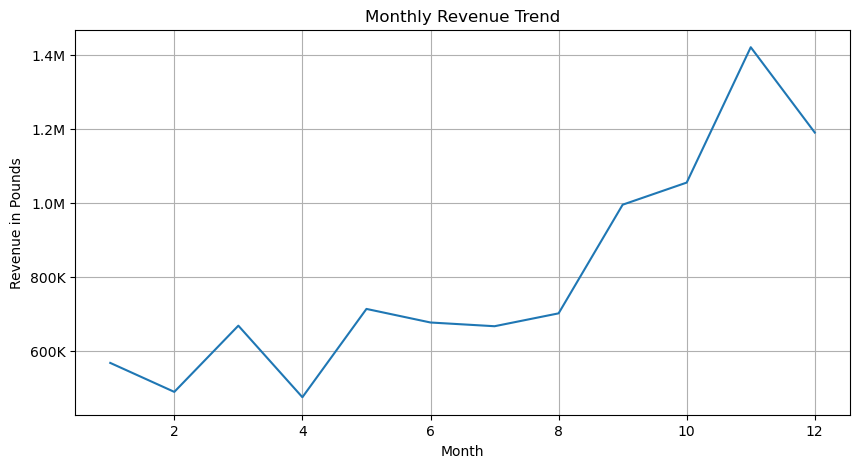

In [85]:
#Monthly Revenue trend using a time series plot
import matplotlib.ticker as ticker
ax = monthly_revenue.plot(kind = 'line', figsize = (10,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue in Pounds')
plt.grid(True)

def currency_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    else:
        return f'{x/1000:.0f}K'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))
plt.show()

**Insight: Revenue Peaks during the fnal quarter of the year**

       The monthly revenue trend reveals a strong seasonal sales pattern. Revenue begins increasing significantly from September and reaches its highest point in November before slightly declining in December. 

    This suggests that customer purchasing activity intensifies during the final quarter of the year, likely due to holiday shopping, Black Friday promotions and festive demand. The business appears to rely heavily on Q4 sales performance, making inventory planning and seasonal marketing especially important during this period.

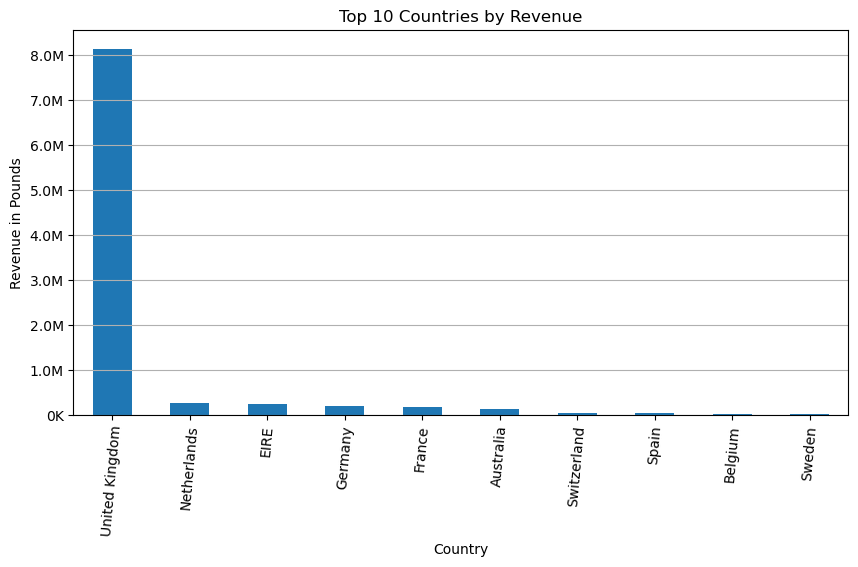

In [95]:
# Revenue by Country in a bar chart
import matplotlib.ticker as ticker
top_countries = country_revenue.head(10)
ax = top_countries.plot(kind = 'bar', figsize = (10,5))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue in Pounds')
plt.xticks(rotation = 85)
plt.grid(axis = 'y')

def currency_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    else:
        return f'{x/1000:.0f}K'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))
plt.show()


**Insight: The United Kingdom generates the highest revenue**

    The bar chart shows that the United Kingdom cntributes overwhelmingly more revenue than any other contry in the dataset. Revenue from the UK exceeds 8 million pounds, while the next highest-performing countries generate less than 300k pounds each.
 
 
    This indicates that the business is heavily concentrated in the UK market, suggesting strong domestic customer demand. However, it also reveals a potential business risk, as the company may be highly dependent on a single geographic market for overall revenue performance.

In [90]:
# Top products by revenue
top_products = df_products.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
Name: Revenue, dtype: float64

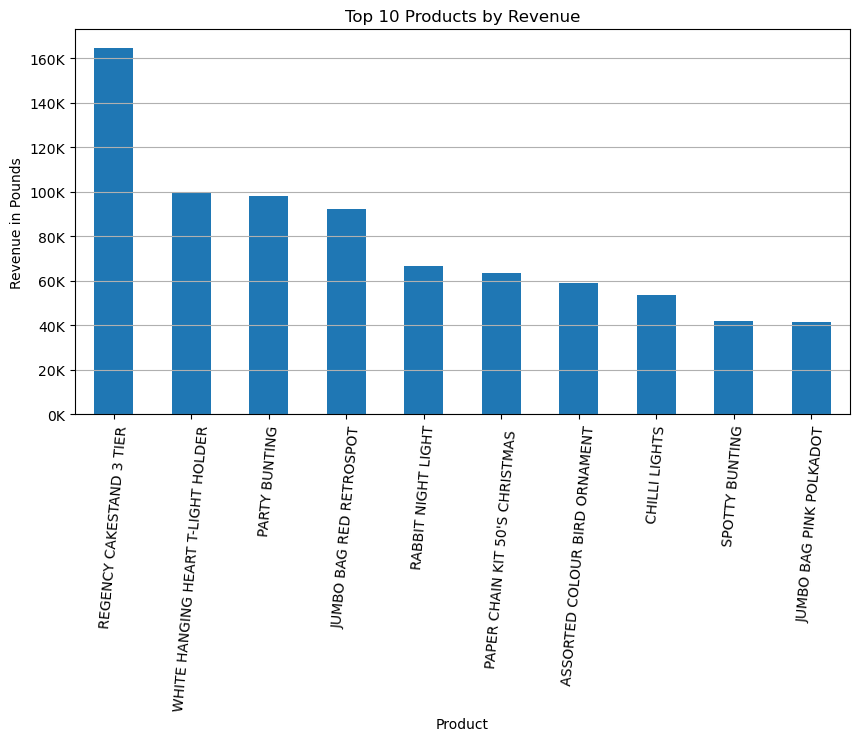

In [94]:

ax = top_products.plot(kind = 'bar', figsize = (10,5))
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue in Pounds')
plt.xticks(rotation = 85)
plt.grid(axis = 'y')

def currency_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    else:
        return f'{x/1000:.0f}K'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))
plt.show()

**Insight: Revenue is driven by a small set of high performing products**
    
    The bar chart shows that a small number of products generate a disproportionately large share of total revenue. The top performing items significantly outperform the rest of the product catalog.

      This suggests that the company's revenue is concentrated in a limited number of high-demand products rather than being evenly distributed across all items.

In [96]:
# Top returned products
top_returned_products = returns.groupby('Description')['Revenue'].sum().sort_values().head(10)
top_returned_products

Description
AMAZON FEE                           -235281.59
PAPER CRAFT , LITTLE BIRDIE          -168469.60
Manual                               -146784.46
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
POSTAGE                               -11871.24
REGENCY CAKESTAND 3 TIER               -9722.55
CRUK Commission                        -7933.43
Bank Charges                           -7340.64
WHITE HANGING HEART T-LIGHT HOLDER     -6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.42
Name: Revenue, dtype: float64

In [100]:
df_clean['Description'].str.contains('fee|postage|bank|amazon|commission', case = False, na = False).sum()

np.int64(7272)

In [101]:
df_clean.shape

(539392, 14)

In [103]:
clean_returns = df_products[df_products['Quantity']<0].copy()

In [107]:
top_returned_products = clean_returns.groupby('Description')['Revenue'].sum().sort_values().head(10)
top_returned_products

Description
PAPER CRAFT , LITTLE BIRDIE          -168469.60
Manual                               -146784.46
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
REGENCY CAKESTAND 3 TIER               -9722.55
WHITE HANGING HEART T-LIGHT HOLDER     -6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.42
Discount                               -5696.22
PANTRY CHOPPING BOARD                  -4803.06
DOORMAT FAIRY CAKE                     -4554.90
GIN + TONIC DIET METAL SIGN            -3775.33
Name: Revenue, dtype: float64

In [108]:
df_products[df_products['Description'].str.contains('discount', case = False, na= False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek,is_non_product
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,12,1,9,Wednesday,False
9038,C537164,D,Discount,-1,2010-12-05 13:21:00,29.29,14527.0,United Kingdom,-29.29,12,5,13,Sunday,False
14498,C537597,D,Discount,-1,2010-12-07 12:34:00,281.00,15498.0,United Kingdom,-281.00,12,7,12,Tuesday,False
19392,C537857,D,Discount,-1,2010-12-08 16:00:00,267.12,17340.0,United Kingdom,-267.12,12,8,16,Wednesday,False
31134,C538897,D,Discount,-1,2010-12-15 09:14:00,5.76,16422.0,United Kingdom,-5.76,12,15,9,Wednesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479868,C577227,D,Discount,-1,2011-11-18 12:06:00,19.82,14527.0,United Kingdom,-19.82,11,18,12,Friday,False
479869,C577227,D,Discount,-1,2011-11-18 12:06:00,16.76,14527.0,United Kingdom,-16.76,11,18,12,Friday,False
493613,C578239,D,Discount,-1,2011-11-23 12:29:00,26.33,14912.0,Italy,-26.33,11,23,12,Wednesday,False
516221,C579884,D,Discount,-1,2011-11-30 17:34:00,20.53,14527.0,United Kingdom,-20.53,11,30,17,Wednesday,False


In [110]:
df_clean['is_non_product']= df_clean['Description'].str.contains('fee|postage|bank|amazon|commission|discount', case = False, na = False)

In [111]:
df_products = df_clean[df_clean['is_non_product']==False].copy()

In [112]:
clean_returns=df_products[df_products['Quantity']<0]

In [113]:
clean_returns

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Day,Hour,DayOfWeek,is_non_product
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,12,1,9,Wednesday,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,12,1,10,Wednesday,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12,1,10,Wednesday,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12,1,10,Wednesday,False
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,12,1,10,Wednesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,-9.13,12,9,9,Friday,False
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,-224.69,12,9,10,Friday,False
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,-54.75,12,9,11,Friday,False
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-1.25,12,9,11,Friday,False


In [114]:
top_returned_products = clean_returns.groupby('Description')['Revenue'].sum().sort_values().head(10)
top_returned_products

Description
PAPER CRAFT , LITTLE BIRDIE          -168469.60
Manual                               -146784.46
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
REGENCY CAKESTAND 3 TIER               -9722.55
WHITE HANGING HEART T-LIGHT HOLDER     -6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.42
PANTRY CHOPPING BOARD                  -4803.06
DOORMAT FAIRY CAKE                     -4554.90
GIN + TONIC DIET METAL SIGN            -3775.33
TEA TIME PARTY BUNTING                 -3692.95
Name: Revenue, dtype: float64

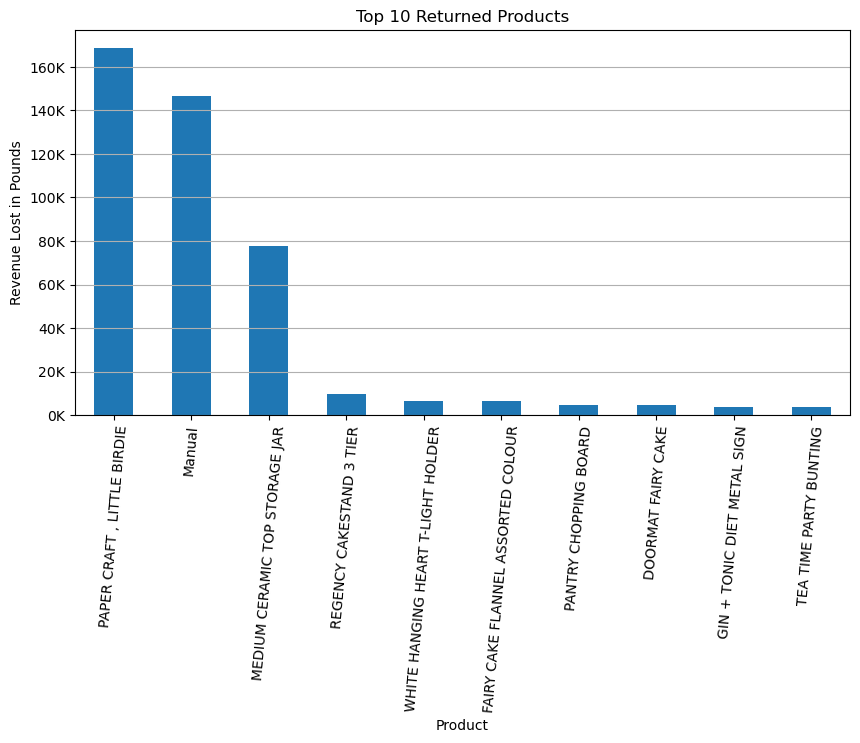

In [117]:
#Top returned products
top_returned_products_abs = abs(top_returned_products)
ax = top_returned_products_abs.plot(kind = 'bar', figsize = (10,5))
plt.title('Top 10 Returned Products')
plt.xlabel('Product')
plt.ylabel('Revenue Lost in Pounds')
plt.xticks(rotation = 85)
plt.grid(axis = 'y')

def currency_format(x, pos):
    return f'{x/1000:.0f}K'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))
plt.show()

**Insight: Return losses are concentrated in specific products**
        
        The visualization shows that a small number of products account for a high share of return-related reveneue losses. Some products generate significantly more negative revenue than others, indicating concentrated return risk.

            This suggests that return issues may be linked to specific products rather than the overall product catalog.

In [134]:

df_customers = df_products[df_products['CustomerID'].notna()]
df_customers['CustomerID']= df_customers['CustomerID'].astype(str).str.replace('.0', "")
df_no_customer = df_products[df_products['CustomerID'].isna()]

In [127]:
df_no_customer['Revenue'].sum()

np.float64(0.0)

In [135]:
df_products['CustomerID'].isna().sum()

np.int64(0)

In [131]:
df_products.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month', 'Day', 'Hour',
       'DayOfWeek', 'is_non_product'],
      dtype='object')

In [129]:
df_no_customer.shape

(0, 14)

In [136]:
#Top Customers by Revenue

top_customers = df_customers.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
nan      1490768.10
14646     277360.67
18102     253205.69
17450     176078.64
14911     131940.21
12415     121539.98
14156     110921.89
17511      87439.41
16684      64332.52
13694      62621.22
Name: Revenue, dtype: float64

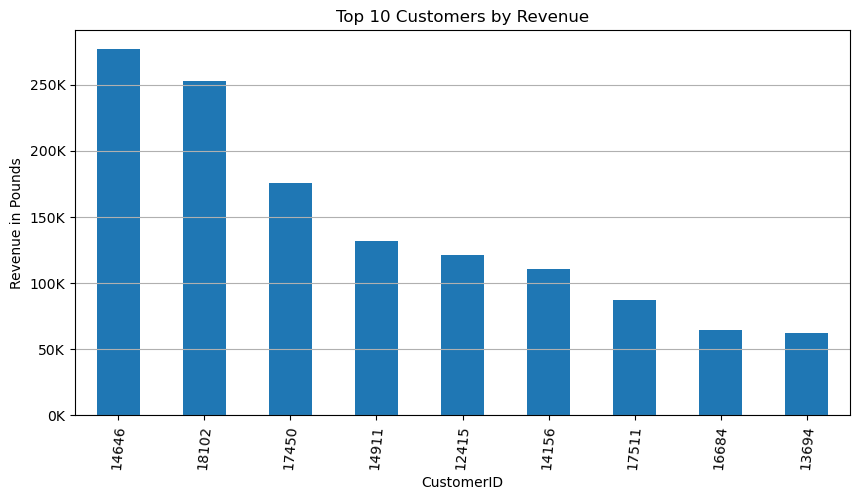

In [137]:
top_customers = top_customers.drop(index = [ 'nan', 'None'], errors = 'ignore')
ax = top_customers.plot(kind = 'bar', figsize = (10,5))
plt.title('Top 10 Customers by Revenue')
plt.xlabel('CustomerID')
plt.ylabel('Revenue in Pounds')
plt.xticks(rotation = 85)
plt.grid(axis = 'y')

def currency_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    else:
        return f'{x/1000:.0f}K'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))
plt.show()

**Insight: Top 10 Customers by Revenue**

        The customer analysis shows a clear concentration of revenue among a smal group of customers. The top customer generates close to 290k pounds, followed by others contributing slightly over 250k and 70k. There is a noticeable decline after the top few customers, indicating that revenue is not evenly distributed across the customer base.

        This pattern suggests the presence of high-value or bulk-purchasing customers, likely representing repeat buyers, wholesale accounts or institutional clients. These customers play a major role in sustaining overall revenue performance, meaning the business is partially dependent on a small set of key customers.

        This concentration is both a strength and risk. While it reflects strong loyalty or high demand from certain clients, it also implies that losing even a few top customers could significantly impact total revenue.

        A key limitation in this analysis is the presence of transactions with missing customerid values (nan). These records could not be attributed to specific customers and therefore were excluded from the customer-level ranking.
       

In [138]:
top10_share = top_customers.sum()/df_customers['Revenue'].sum()*100
top10_share

np.float64(13.347915842942074)

A small number of customers contribute 13% of total revenue, indicating moderate concentration without excessive dependency risk.